In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1
import requests
from scipy.stats import spearmanr

In [2]:
def get_race_results(Result):

    race = Result.results[["Abbreviation","Position"]]
    race.rename(columns={"Abbreviation":"Driver"},inplace=True)

    return race

In [3]:
season = 2026
race = 'Monaco'

Result = fastf1.get_session(season, race, 'R')
Result.load()


result = get_race_results(Result)



req         WARNING 	DEFAULT CACHE ENABLED! (13.2 GB) /home/satyam/.cache/fastf1
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '6', '81', '30', '41', '10', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16'

In [4]:
result.reset_index(inplace=True, drop=True)

In [5]:
result

,Driver,Position
0,ANT,1.0
1,HAM,2.0
2,HAD,3.0
3,PIA,4.0
4,LAW,5.0
5,LIN,6.0
6,GAS,7.0
7,ALB,8.0
8,OCO,9.0
9,ALO,10.0


In [6]:
PRE = pd.read_csv("Data/PredictedData.csv")
PRE

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart,Predicted_Result,Predicted_Pos
0,ANT,Mercedes,9.000000,17.000000,31.0,74.537,73.529,72.720,23.736771,42.723088,...,17,93.315118,7.824569,19,6.691904,219.0,28689.0,1.0,4.686387,1
1,LEC,Ferrari,8.000000,6.000000,21.0,73.978,73.137,73.047,23.069171,41.336171,...,11,90.121062,4.630513,14,5.881308,588.0,11025.0,8.0,4.759162,2
2,HAM,Ferrari,8.666667,8.333333,21.0,74.204,73.026,73.051,24.465500,41.936057,...,18,93.499432,8.008884,21,8.259933,441.0,10584.0,9.0,4.847397,3
3,RUS,Mercedes,7.666667,9.833333,31.0,74.983,73.405,73.483,23.428030,42.588500,...,6,90.983917,5.493369,9,4.352733,1314.0,19272.0,24.0,6.348409,4
4,VER,Red Bull Racing,7.666667,8.833333,17.5,74.491,73.194,73.662,21.880200,38.904800,...,3,85.490548,0.000000,1,0.000000,114.0,2451.0,10.0,7.538481,5
5,PIA,McLaren,4.666667,9.833333,16.5,75.565,74.088,73.698,23.133323,40.818367,...,21,91.649578,6.159030,16,6.427093,742.0,5088.0,42.0,8.450545,6
6,NOR,McLaren,6.666667,12.333333,16.5,75.291,75.274,74.006,23.993625,41.239429,...,22,93.829768,8.339219,22,9.792442,848.0,6148.0,72.0,9.188462,7
7,HAD,Red Bull Racing,12.333333,6.166667,17.5,76.148,74.087,73.877,23.117913,40.684348,...,19,91.060629,5.570081,18,6.488503,285.0,798.0,40.0,9.212705,8
8,GAS,Alpine,11.000000,5.500000,9.0,75.828,74.497,74.480,24.386378,39.974889,...,4,89.212176,3.721628,6,3.805750,315.0,700.0,117.0,9.454453,9
9,LAW,Racing Bulls,11.000000,5.500000,3.0,76.431,74.785,74.587,22.825971,41.609743,...,12,90.369214,4.878666,13,5.818308,210.0,336.0,150.0,10.901116,10


In [7]:
PRE.set_index("Driver", inplace=True)
result.set_index("Driver", inplace=True)

Final = result.copy()
Final["Predicted_Pos"] = PRE["Predicted_Pos"]

PRE.reset_index(inplace=True)
Final.reset_index(inplace=True)
result.reset_index(inplace=True)

Final

,Driver,Position,Predicted_Pos
0,ANT,1.0,1
1,HAM,2.0,3
2,HAD,3.0,8
3,PIA,4.0,6
4,LAW,5.0,10
5,LIN,6.0,12
6,GAS,7.0,9
7,ALB,8.0,15
8,OCO,9.0,14
9,ALO,10.0,22


In [8]:

rho, p_value = spearmanr(Final['Position'],Final['Predicted_Pos'])

In [9]:
print(f"{rho}, {p_value}")

0.34839073969508755, 0.11206951041950931


In [10]:
podium = Final.loc[:,["Driver"]]
print("\n Final Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Final): {rho:.2f}")


 Final Standing
🥇P1: ANT
🥈P2: HAM
🥉P3: HAD
P4: PIA
P5: LAW
P6: LIN
P7: GAS
P8: ALB
P9: OCO
P10: ALO
P11: BOR
P12: RUS
Spearman Rank (Final): 0.35


In [11]:
PRE.set_index("Driver", inplace=True)
result.set_index("Driver", inplace=True)

df = PRE.copy()
df["Actual_Pos"] = result["Position"]


PRE.reset_index(inplace=True)
Final.reset_index(inplace=True,drop=True)

df.reset_index("Driver", inplace=True)

In [12]:
df

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart,Predicted_Result,Predicted_Pos,Actual_Pos
0,ANT,Mercedes,9.000000,17.000000,31.0,74.537,73.529,72.720,23.736771,42.723088,...,93.315118,7.824569,19,6.691904,219.0,28689.0,1.0,4.686387,1,1.0
1,LEC,Ferrari,8.000000,6.000000,21.0,73.978,73.137,73.047,23.069171,41.336171,...,90.121062,4.630513,14,5.881308,588.0,11025.0,8.0,4.759162,2,17.0
2,HAM,Ferrari,8.666667,8.333333,21.0,74.204,73.026,73.051,24.465500,41.936057,...,93.499432,8.008884,21,8.259933,441.0,10584.0,9.0,4.847397,3,2.0
3,RUS,Mercedes,7.666667,9.833333,31.0,74.983,73.405,73.483,23.428030,42.588500,...,90.983917,5.493369,9,4.352733,1314.0,19272.0,24.0,6.348409,4,12.0
4,VER,Red Bull Racing,7.666667,8.833333,17.5,74.491,73.194,73.662,21.880200,38.904800,...,85.490548,0.000000,1,0.000000,114.0,2451.0,10.0,7.538481,5,22.0
5,PIA,McLaren,4.666667,9.833333,16.5,75.565,74.088,73.698,23.133323,40.818367,...,91.649578,6.159030,16,6.427093,742.0,5088.0,42.0,8.450545,6,4.0
6,NOR,McLaren,6.666667,12.333333,16.5,75.291,75.274,74.006,23.993625,41.239429,...,93.829768,8.339219,22,9.792442,848.0,6148.0,72.0,9.188462,7,19.0
7,HAD,Red Bull Racing,12.333333,6.166667,17.5,76.148,74.087,73.877,23.117913,40.684348,...,91.060629,5.570081,18,6.488503,285.0,798.0,40.0,9.212705,8,3.0
8,GAS,Alpine,11.000000,5.500000,9.0,75.828,74.497,74.480,24.386378,39.974889,...,89.212176,3.721628,6,3.805750,315.0,700.0,117.0,9.454453,9,7.0
9,LAW,Racing Bulls,11.000000,5.500000,3.0,76.431,74.785,74.587,22.825971,41.609743,...,90.369214,4.878666,13,5.818308,210.0,336.0,150.0,10.901116,10,5.0


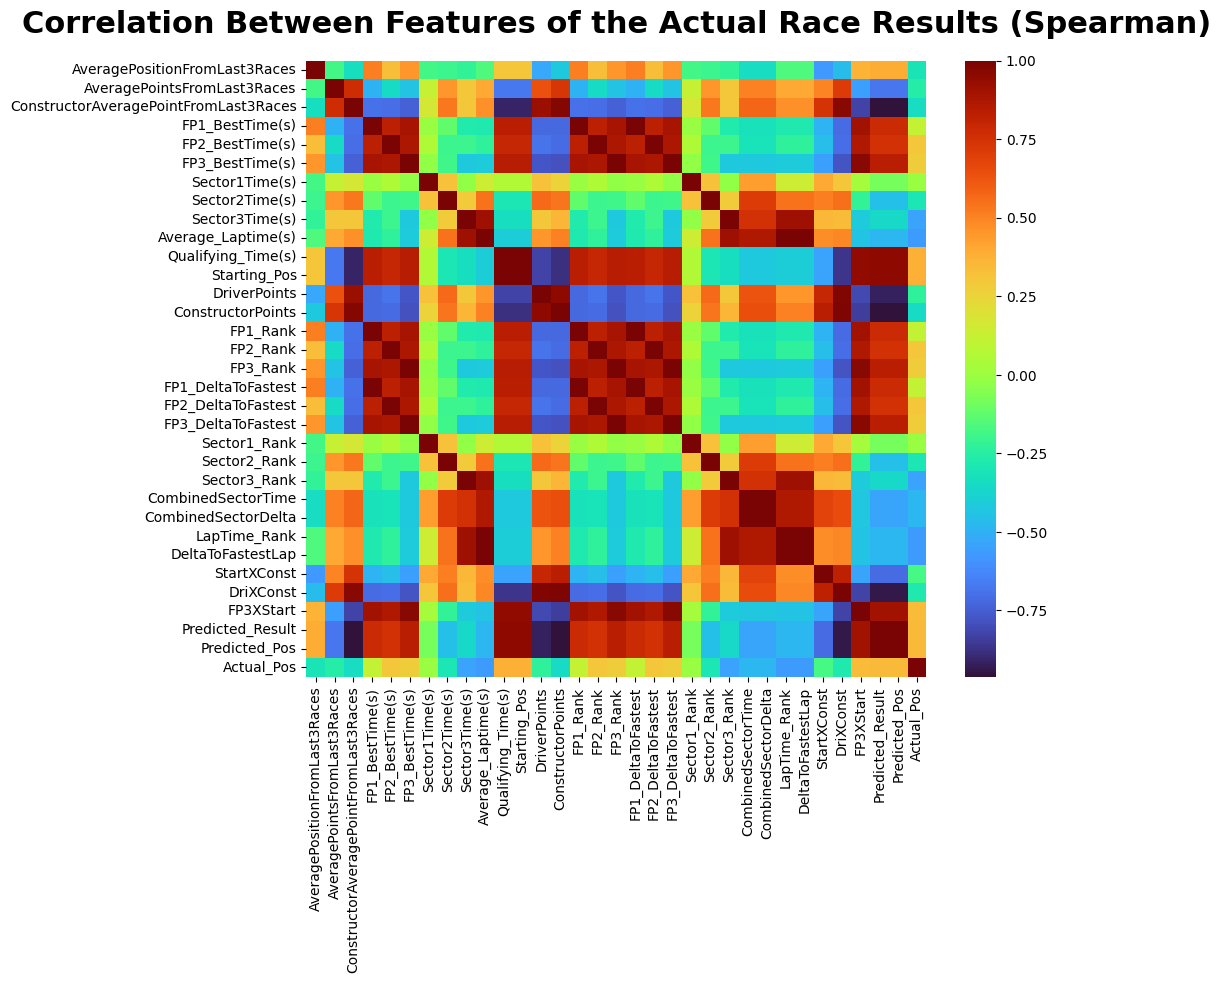

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=["Driver","Constructor"]).corr(method='spearman'), cmap='turbo')

plt.title('Correlation Between Features of the Actual Race Results (Spearman)', fontsize=22, fontweight='bold',pad=20)
plt.savefig('Plots/Result_Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


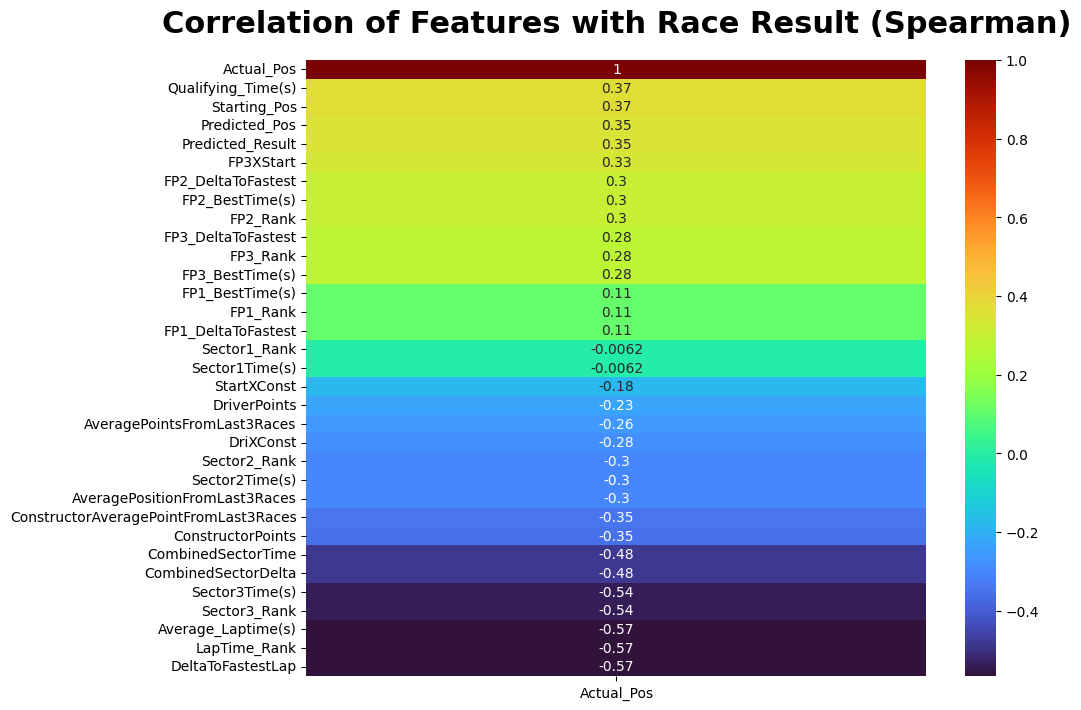

In [14]:
corr = df.drop(columns=["Driver","Constructor"]).corr(method='spearman')[['Actual_Pos']].sort_values(by='Actual_Pos', ascending=False)
plt.figure(figsize=(10,8))
plt.title('Correlation of Features with Race Result (Spearman)', fontsize=22, fontweight='bold',pad=20)
sns.heatmap(corr, annot=True, cmap='turbo')
plt.savefig('Plots/Result_Feature_RaceResult_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
Final["Position_Diff"] = Final["Predicted_Pos"] - Final["Position"]
Final

,Driver,Position,Predicted_Pos,Position_Diff
0,ANT,1.0,1,0.0
1,HAM,2.0,3,1.0
2,HAD,3.0,8,5.0
3,PIA,4.0,6,2.0
4,LAW,5.0,10,5.0
5,LIN,6.0,12,6.0
6,GAS,7.0,9,2.0
7,ALB,8.0,15,7.0
8,OCO,9.0,14,5.0
9,ALO,10.0,22,12.0


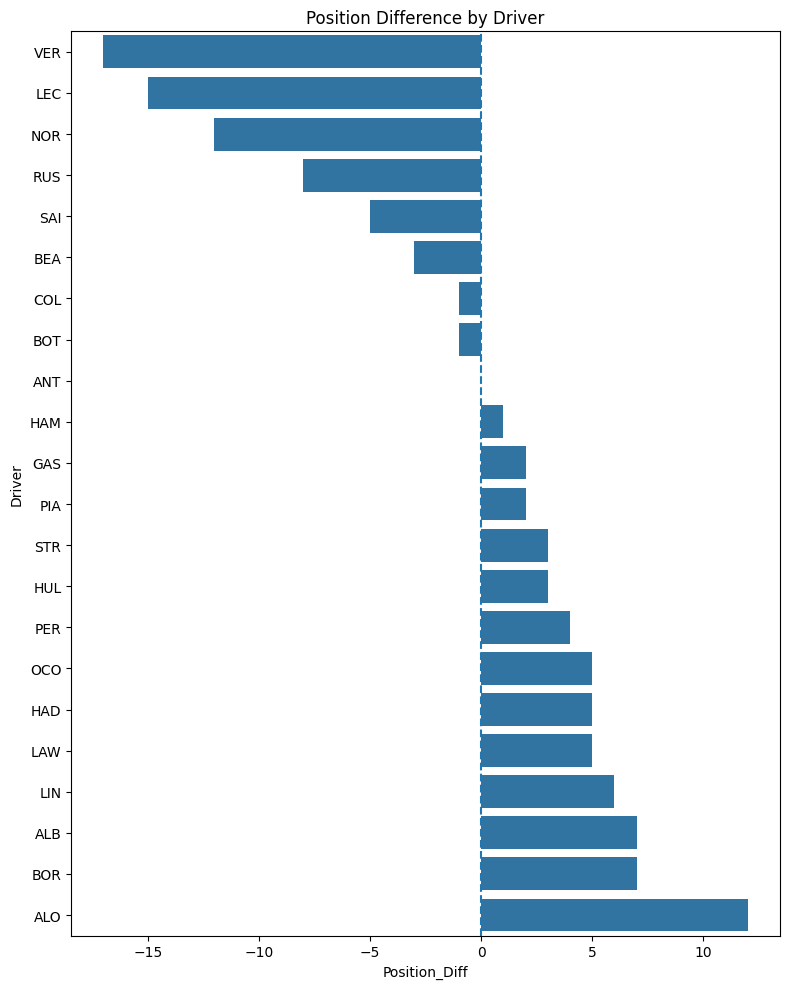

In [24]:
Final_sorted = Final.sort_values("Position_Diff")

plt.figure(figsize=(8,10))

sns.barplot(
    data=Final_sorted,
    y="Driver",
    x="Position_Diff"
)

plt.axvline(0, linestyle="--" )
plt.title("Position Difference by Driver")

plt.tight_layout()
plt.savefig('Plots/Position_Difference_by_Driver.png', dpi=300, bbox_inches='tight')

plt.show()